In [1]:
import sys

print(sys.executable)

c:\Users\ASUS\OneDrive\Desktop\NLP35\NLP_Group_35\venv\Scripts\python.exe


In [2]:
import xgboost

print(xgboost.__version__)

3.2.0


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import joblib
import os

In [4]:
df = pd.read_csv(
    "../data/processed/customer_support_en.csv"
)

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text_length,clean_text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,544,dear customer support teamnni am writing to re...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,534,dear customer support teamnni hope this messag...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,605,dear customer support teamnni hope this messag...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,677,dear support teamnni hope this message reaches...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN,646,dear customer supportnni hope this message rea...


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (16338, 18)

Columns:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'text_length', 'clean_text']


In [6]:
df["queue"].value_counts()

queue
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64

In [7]:
df["clean_text"].head()

0    dear customer support teamnni am writing to re...
1    dear customer support teamnni hope this messag...
2    dear customer support teamnni hope this messag...
3    dear support teamnni hope this message reaches...
4    dear customer supportnni hope this message rea...
Name: clean_text, dtype: str

In [8]:
df["clean_text"].isnull().sum()

np.int64(0)

In [9]:
X = df["clean_text"]

y = df["queue"]

In [10]:
print(X.shape)

print(y.shape)

(16338,)
(16338,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("Train:", X_train.shape)

print("Test:", X_test.shape)

Train: (13070,)
Test: (3268,)


TF-IDF Vectorization

In [13]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

In [14]:
X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

In [15]:
print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(13070, 5000)
(3268, 5000)


Encode Labels

In [16]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

In [17]:
label_encoder.classes_

array(['Billing and Payments', 'Customer Service', 'General Inquiry',
       'Human Resources', 'IT Support', 'Product Support',
       'Returns and Exchanges', 'Sales and Pre-Sales',
       'Service Outages and Maintenance', 'Technical Support'],
      dtype=object)

Build XGBoost Model

In [18]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),

    n_estimators=200,

    max_depth=6,

    learning_rate=0.1,

    random_state=42,

    eval_metric="mlogloss"
)

In [19]:
xgb_model.fit(
    X_train_tfidf,
    y_train_encoded
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [20]:
predictions = xgb_model.predict(
    X_test_tfidf
)

In [21]:
accuracy = accuracy_score(
    y_test_encoded,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.5305997552019583


Classification Report

In [22]:
print(
    classification_report(
        y_test_encoded,
        predictions,
        target_names=label_encoder.classes_
    )
)

                                 precision    recall  f1-score   support

           Billing and Payments       0.91      0.70      0.79       319
               Customer Service       0.45      0.40      0.42       482
                General Inquiry       1.00      0.26      0.41        47
                Human Resources       0.95      0.27      0.42        70
                     IT Support       0.73      0.29      0.41       388
                Product Support       0.49      0.40      0.44       615
          Returns and Exchanges       0.77      0.20      0.32       164
            Sales and Pre-Sales       0.93      0.27      0.42       103
Service Outages and Maintenance       0.82      0.60      0.69       133
              Technical Support       0.45      0.83      0.59       947

                       accuracy                           0.53      3268
                      macro avg       0.75      0.42      0.49      3268
                   weighted avg       0.60      0

Confusion Matrix

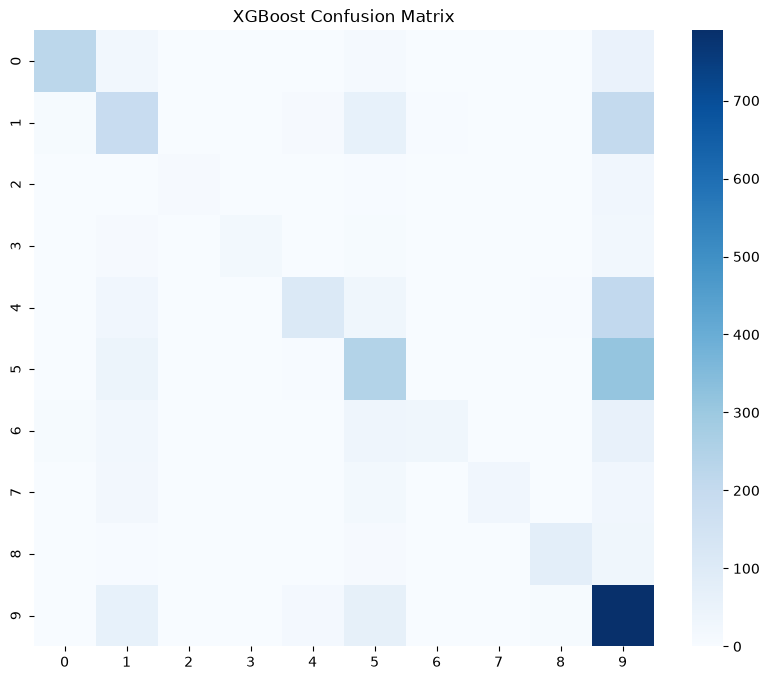

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_encoded,
    predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

In [24]:
os.makedirs(
    "../models/member3",
    exist_ok=True
)

In [25]:
joblib.dump(
    xgb_model,
    "../models/member3/xgboost.pkl"
)

['../models/member3/xgboost.pkl']

In [26]:
joblib.dump(
    vectorizer,
    "../models/member3/tfidf_vectorizer.pkl"
)

['../models/member3/tfidf_vectorizer.pkl']

In [27]:
joblib.dump(
    label_encoder,
    "../models/member3/label_encoder.pkl"
)

['../models/member3/label_encoder.pkl']

In [28]:
os.listdir(
    "../models/member3"
)

['label_encoder.pkl', 'tfidf_vectorizer.pkl', 'xgboost.pkl']

In [29]:
import pandas as pd

english_df = pd.read_csv(
    "../data/processed/customer_support_en.csv"
)

In [30]:
english_df.shape


(16338, 18)

In [31]:
english_df["queue"].nunique()

10

In [32]:
import os

os.getcwd()

'c:\\Users\\ASUS\\OneDrive\\Desktop\\NLP35\\NLP_Group_35\\notebooks'

In [33]:
import os

os.listdir("..")

['.git',
 '.gitignore',
 'data',
 'docs',
 'LICENSE',
 'models',
 'notebooks',
 'README.md',
 'reports',
 'requirements.txt',
 'screenshots',
 'src',
 'venv']

In [34]:
os.listdir("../models")

['member3']

In [36]:
import os

os.listdir("../models/member3")

['label_encoder.pkl', 'tfidf_vectorizer.pkl', 'xgboost.pkl']

In [37]:
import os

os.path.exists("../models/member3/xgboost.pkl")
os.path.exists("../models/member3/tfidf_vectorizer.pkl")
os.path.exists("../models/member3/label_encoder.pkl")

True

In [38]:
os.listdir("../models/member3")

['label_encoder.pkl', 'tfidf_vectorizer.pkl', 'xgboost.pkl']